In [1]:
%%capture --no-stderr
%pip install --quiet -U langgraph langchain-core langchain-perplexity

In [2]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("PPLX_API_KEY")

PPLX_API_KEY:  ········


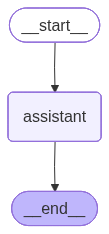

In [3]:
from typing_extensions import TypedDict
from typing import List

from IPython.display import Image, display

from langchain_perplexity import ChatPerplexity
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import MemorySaver

class State(MessagesState):
    timeline_label: str

llm = ChatPerplexity(model="sonar-pro")

def assistant(state: State) -> State:
    messages: List[BaseMessage] = state.get("messages", [])
    response = llm.invoke(messages)
    return {
        "messages": messages + [response],
        "timeline_label": state.get("timeline_label", "main"),
    }

workflow = StateGraph(State)
workflow.add_node("assistant", assistant)
workflow.set_entry_point("assistant")
workflow.add_edge("assistant", END)

memory = MemorySaver()
graph = workflow.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [4]:
from langchain_core.messages import HumanMessage

config_main = {"configurable": {"thread_id": "time-travel-main"}}

initial_state = {
    "messages": [HumanMessage(content="Help me plan a productive morning routine.")],
    "timeline_label": "main",
}

print("Running the main timeline...\n")
last_state = None
for event in graph.stream(initial_state, config=config_main, stream_mode="values"):
    last_state = event
    event["messages"][-1].pretty_print()
    print("-" * 40)

print("Finished initial run on the main timeline.")

Running the main timeline...

================================ Human Message =================================

Help me plan a productive morning routine.
----------------------------------------
================================== Ai Message ==================================

# Planning Your Productive Morning Routine

A productive morning routine starts the night before and builds in time for physical movement, mental clarity, and intentional planning[5]. Here's how to create one that works for you.

## Preparation Matters

Your morning success begins with evening preparation[5]. Set yourself up by laying out workout clothes, setting up the coffee maker, placing water on your nightstand, and enabling night mode on your phone. Aim for 7-9 hours of sleep and set your bedtime accordingly[5].

## Key Components of a Productive Morning

**Wake up early and avoid the snooze button.** Give yourself enough time to move through your routine without rushing[2]. Consider keeping your alarm cloc

In [5]:
print("Retrieving stored state for the main timeline...\n")
state_main = graph.get_state(config_main)
state_main

Retrieving stored state for the main timeline...



StateSnapshot(values={'messages': [HumanMessage(content='Help me plan a productive morning routine.', additional_kwargs={}, response_metadata={}, id='82a8e8e2-07e6-43c2-8bb5-d7f8517d9a09'), AIMessage(content="# Planning Your Productive Morning Routine\n\nA productive morning routine starts the night before and builds in time for physical movement, mental clarity, and intentional planning[5]. Here's how to create one that works for you.\n\n## Preparation Matters\n\nYour morning success begins with evening preparation[5]. Set yourself up by laying out workout clothes, setting up the coffee maker, placing water on your nightstand, and enabling night mode on your phone. Aim for 7-9 hours of sleep and set your bedtime accordingly[5].\n\n## Key Components of a Productive Morning\n\n**Wake up early and avoid the snooze button.** Give yourself enough time to move through your routine without rushing[2]. Consider keeping your alarm clock in the bathroom—once you're up and in that room, you're l

In [6]:
print("Simulating a fork: starting an alternate timeline from the original user question.\n")

# We take the first user message and branch the conversation in a new direction
fork_config = {"configurable": {"thread_id": "time-travel-alt"}}

fork_state = {
    "messages": [HumanMessage(content="Instead of morning, help me design a relaxing evening routine.")],
    "timeline_label": "alternate",
}

for event in graph.stream(fork_state, config=fork_config, stream_mode="values"):
    event["messages"][-1].pretty_print()
    print("-" * 40)

print("Alternate timeline completed.")

Simulating a fork: starting an alternate timeline from the original user question.

================================ Human Message =================================

Instead of morning, help me design a relaxing evening routine.
----------------------------------------
================================== Ai Message ==================================

A relaxing evening routine creates a gentle transition from your busy day to restful sleep, allowing your mind and body to gradually shift into a calmer state[2]. Rather than jumping straight to bed, you want to build in time to decompress and signal to your nervous system that it's time to wind down[2].

## Structure Your Routine with a Clear Start Time

Begin your evening routine about **one to two hours before bed**[2]. This doesn't need to be rigidly scheduled—instead, pick a concrete cue that marks the shift, such as closing your laptop, turning off main lights, or changing into comfortable clothes[2]. These small signals help your bod

In [7]:
print("Creating a second alternate timeline focusing on fitness.\n")

fork_config_2 = {"configurable": {"thread_id": "time-travel-fitness"}}

fork_state_2 = {
    "messages": [HumanMessage(content="From the same starting point, suggest a simple home workout routine.")],
    "timeline_label": "fitness_branch",
}

for event in graph.stream(fork_state_2, config=fork_config_2, stream_mode="values"):
    event["messages"][-1].pretty_print()
    print("-" * 40)

print("Fitness branch timeline completed.")

Creating a second alternate timeline focusing on fitness.

================================ Human Message =================================

From the same starting point, suggest a simple home workout routine.
----------------------------------------
================================== Ai Message ==================================

# A Simple Home Workout Routine

Here's an effective beginner-friendly home workout routine that requires no equipment and takes about 15-20 minutes to complete[1].

## The Routine

Complete **2 sets of 10 to 15 reps** of each exercise, with **30 seconds to 1 minute of rest** between moves[1].

**Lower Body**

Start with **chair squats**, which help improve the strength and function of your muscles, tendons, and bones[1]. Stand in front of a chair with your feet shoulder-width apart, hinge at your hips and bend your knees until your bottom touches the chair, then push back up through your heels.

Follow with **stationary lunges** to target your quads, hamstri

In [8]:
print("Resuming the original main timeline with a follow-up question.\n")

followup_state = {
    "messages": [HumanMessage(content="Now summarize my ideal day in three sentences.")],
    "timeline_label": "main",
}

for event in graph.stream(followup_state, config=config_main, stream_mode="values"):
    event["messages"][-1].pretty_print()
    print("-" * 40)

print("Main timeline resumed and completed.")

Resuming the original main timeline with a follow-up question.

================================ Human Message =================================

Now summarize my ideal day in three sentences.
----------------------------------------
================================== Ai Message ==================================

I don't have enough information to summarize your ideal day in three sentences. You haven't provided me with details about your goals, work schedule, preferences, or lifestyle. 

To create a personalized summary of your ideal day, I would need to know things like: What time do you wake up? What are your main priorities—work, health, family, creative pursuits? How long do you want to work versus rest? What activities make you feel fulfilled?

If you'd like, you can share these details and I can help you craft a three-sentence description of your ideal day.
----------------------------------------
Main timeline resumed and completed.
